In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# Path to your output file
input_file = "/Users/junjie/lab10spark/weightedaverageandvariance.txt"

# Prepare lists to hold parsed data
product_ids = []
average_ratings = []
variances = []
review_counts = []

with open(input_file, 'r', encoding='utf-8') as f:
    for line in f:
        # Split on the first tab
        parts = line.strip().split('\t', 1)
        if len(parts) == 2:
            product_id = parts[0]
            metrics_str = parts[1]

            # Parse the JSON portion
            # e.g., {"average_rating":4.47,"variance":0.84,"review_count":17}
            try:
                metrics = json.loads(metrics_str)
                product_ids.append(product_id)
                average_ratings.append(metrics.get("average_rating", None))
                variances.append(metrics.get("variance", None))
                review_counts.append(metrics.get("review_count", None))
            except json.JSONDecodeError:
                print(f"Skipping invalid JSON: {metrics_str}")
        else:
            print(f"Skipping malformed line: {line}")

# Create a DataFrame
df = pd.DataFrame({
    "product_id": product_ids,
    "average_rating": average_ratings,
    "variance": variances,
    "review_count": review_counts
})

print(df.head())

# Convert columns to numeric just in case they're strings
df["average_rating"] = pd.to_numeric(df["average_rating"])
df["variance"] = pd.to_numeric(df["variance"])
df["review_count"] = pd.to_numeric(df["review_count"])


   product_id  average_rating  variance  review_count
0  0007922582            2.00      0.00             1
1  0008288194            3.00      0.00             1
2  0028179714            4.67      0.22             3
3  0060501960            4.47      0.84            17
4  0063052164            5.00      0.00             4


In [2]:
print("Descriptive Stats:")
print(df[["average_rating", "variance", "review_count"]].describe())


Descriptive Stats:
       average_rating       variance   review_count
count   137249.000000  137249.000000  137249.000000
mean         3.866956       1.063877      33.304192
std          1.115026       1.172091     198.066359
min          1.000000       0.000000       1.000000
25%          3.330000       0.000000       1.000000
50%          4.080000       0.650000       4.000000
75%          4.800000       2.000000      14.000000
max          5.000000       4.000000   17893.000000


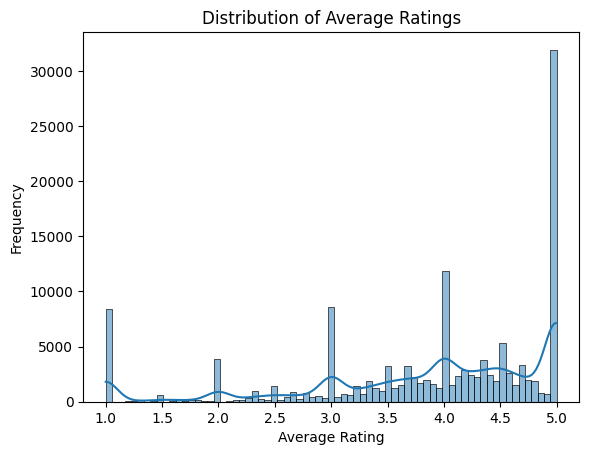

In [3]:
import seaborn as sns

sns.histplot(df["average_rating"], kde=True)
plt.title("Distribution of Average Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")
plt.show()


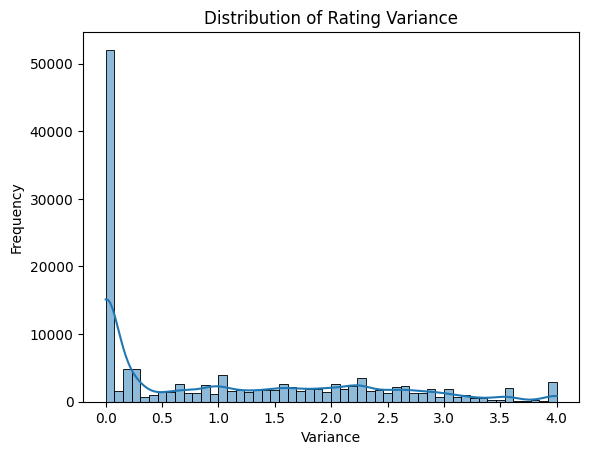

In [4]:
sns.histplot(df["variance"], kde=True)
plt.title("Distribution of Rating Variance")
plt.xlabel("Variance")
plt.ylabel("Frequency")
plt.show()


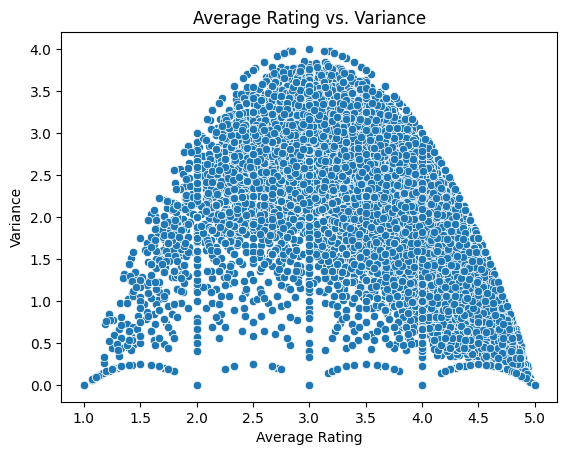

In [5]:
sns.scatterplot(x="average_rating", y="variance", data=df)
plt.title("Average Rating vs. Variance")
plt.xlabel("Average Rating")
plt.ylabel("Variance")
plt.show()

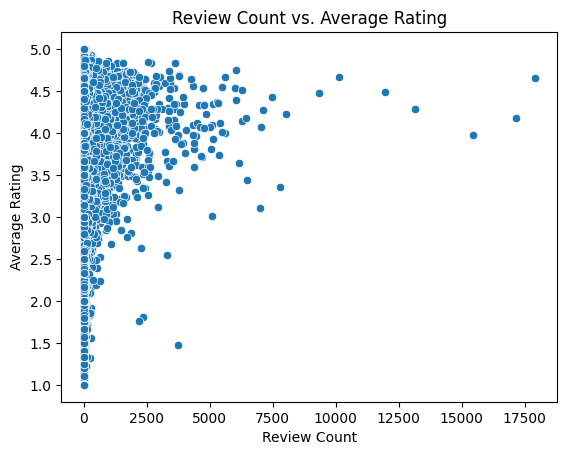

In [6]:
sns.scatterplot(x="review_count", y="average_rating", data=df)
plt.title("Review Count vs. Average Rating")
plt.xlabel("Review Count")
plt.ylabel("Average Rating")
plt.show()

In [8]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load aggregated MapReduce output
records = []
with open("part-r-00000") as f:
    for line in f:
        pid, metrics = line.strip().split("\t", 1)
        data = json.loads(metrics)
        data["product_id"] = pid
        records.append(data)
df = pd.DataFrame(records)

# 2️⃣ Merge metadata & business metrics
df_meta = pd.read_csv("product_metadata.csv")
df_business = pd.read_csv("business_metrics.csv")
df = df.merge(df_meta, on="product_id", how="left").merge(df_business, on="product_id", how="left")

# === Segment by Category/Brand/Price ===
plt.figure()
sns.scatterplot(x="average_rating", y="variance", hue="category", style="brand", size="price", data=df)
plt.title("Avg Rating vs Variance — Colored by Category, Styled by Brand")
plt.xlabel("Average Rating")
plt.ylabel("Variance")
plt.legend(bbox_to_anchor=(1,1))
plt.show()

# === Outlier Analysis ===
outliers = df[(df["variance"] > 2) | (df["average_rating"] < 2) | (df["average_rating"] > 4.8)]
print("Outliers:\n", outliers[["product_id","average_rating","variance","review_count"]])

# === Time Dimension ===
reviews = pd.read_json("cleanedreviews.jsonl", lines=True)
reviews["timestamp"] = pd.to_datetime(reviews["timestamp"], unit="ms")
reviews["month"] = reviews["timestamp"].dt.to_period("M")
time_df = reviews.groupby(["parent_asin","month"]).rating.agg(["mean","var","count"]).reset_index()
time_df.columns = ["product_id","month","avg_rating","variance","review_count"]

# Plot for a single example product
prod = time_df["product_id"].unique()[0]
sub = time_df[time_df.product_id==prod]
plt.figure()
plt.plot(sub["month"].astype(str), sub["avg_rating"], marker="o")
plt.title(f"Rating Trend for {prod}")
plt.xlabel("Month")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

# === Multi‑KPI Correlation ===
plt.figure()
sns.scatterplot(x="sales_volume", y="average_rating", size="review_count", hue="return_rate", data=df)
plt.title("Sales vs Rating — Sized by Review Count, Colored by Return Rate")
plt.xlabel("Sales Volume")
plt.ylabel("Average Rating")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'product_metadata.csv'